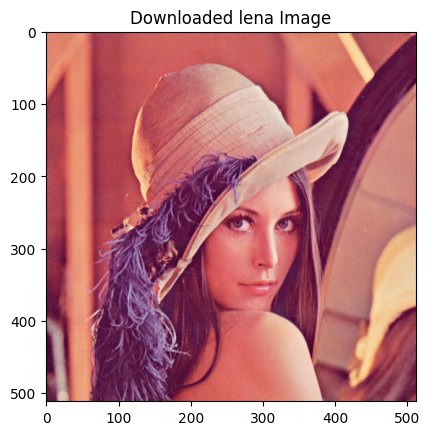

In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

def download_github_image(raw_url):
    response = requests.get(raw_url)
    if response.status_code == 200:
        img_file = BytesIO(response.content)
        img = Image.open(img_file)
        return np.array(img)
    else:
        print("Error: Could not download image. Check your link!")
        return None

my_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
image_data = download_github_image(my_url)

if image_data is not None:
    plt.imshow(image_data)
    plt.title("Downloaded lena Image")
    plt.show()

### Step‑by‑Step Implementation (Question 4, Part 1)
We’ll tackle the problem in three stages:  

1. **Corrupt:** Inject a sine wave pattern into the image.  
2. **Detect:** Transform the image into the frequency domain (FFT) to reveal the spikes caused by the noise.  
3. **Restore:** Apply a mask to block those spikes and convert back to the spatial domain.  

---
#### 1. Adding the Noise  
The corrupted image is defined as:  


$$I'(x,y) = I(x,y) + A \cdot \sin\big(2\pi(f_x x + f_y y)\big)$$


This adds a sinusoidal wave that repeats $(f_x)$ times horizontally and $(f_y)$ times vertically across the normalized coordinates.  

---

#### 2. The Notch Filter  
A **Notch Reject filter** is simply a mask:  
- Value = 1.0 everywhere (pass)  
- Value = 0.0 at specific coordinates (reject)  

Because the FFT is symmetric, noise at frequency $(u, v)$ produces spikes at two mirrored positions: $(+u, +v)$ and $(-u, -v)$. To fully remove the interference, both must be blocked.  

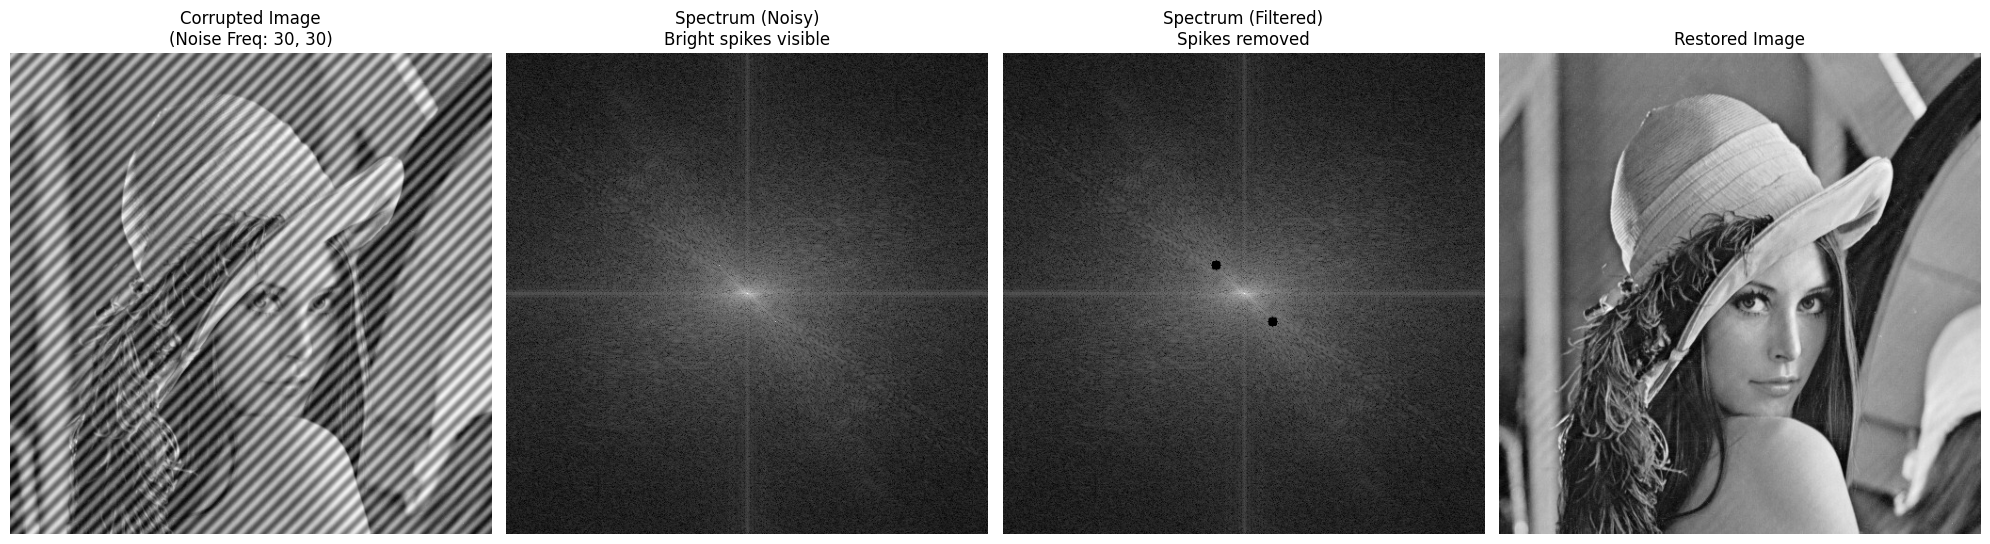

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def solve_q4_part1(img):
    # Convert to grayscale if input is RGB
    if img.ndim == 3:
        img = np.dot(img[..., :3], [0.299, 0.587, 0.114])
    img = img / 255.0
    rows, cols = img.shape

    # --- Step 1: Add synthetic periodic noise ---
    fx, fy = 30, 30   # frequency components (horizontal, vertical)
    amp = 0.3         # amplitude of the sine wave

    x = np.arange(cols)
    y = np.arange(rows)
    xx, yy = np.meshgrid(x, y)

    noise = amp * np.sin(2 * np.pi * (fx * xx / cols + fy * yy / rows))
    img_noisy = img + noise

    # --- Step 2: Compute FFT ---
    f = np.fft.fft2(img_noisy)
    fshift = np.fft.fftshift(f)  # move DC component to center
    magnitude_noisy = 20 * np.log(np.abs(fshift) + 1)

    # --- Step 3: Design notch reject filter ---
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), np.uint8)
    r = 5  # radius of the notch

    # spike locations (symmetric around center)
    centers = [(crow + fy, ccol + fx), (crow - fy, ccol - fx)]
    y_grid, x_grid = np.ogrid[:rows, :cols]

    for cy, cx in centers:
        mask_area = (x_grid - cx) ** 2 + (y_grid - cy) ** 2 <= r ** 2
        mask[mask_area] = 0

    # --- Step 4: Apply filter & inverse FFT ---
    fshift_filtered = fshift * mask
    magnitude_filtered = 20 * np.log(np.abs(fshift_filtered) + 1)

    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_restored = np.abs(np.fft.ifft2(f_ishift))

    # --- Step 5: Visualization ---
    fig, ax = plt.subplots(1, 4, figsize=(20, 6))

    ax[0].imshow(img_noisy, cmap='gray')
    ax[0].set_title(f"Corrupted Image\n(Noise Freq: {fx}, {fy})")
    ax[0].axis('off')

    ax[1].imshow(magnitude_noisy, cmap='gray')
    ax[1].set_title("Spectrum (Noisy)\nBright spikes visible")
    ax[1].axis('off')

    ax[2].imshow(magnitude_filtered, cmap='gray')
    ax[2].set_title("Spectrum (Filtered)\nSpikes removed")
    ax[2].axis('off')

    ax[3].imshow(img_restored, cmap='gray')
    ax[3].set_title("Restored Image")
    ax[3].axis('off')

    plt.tight_layout()
    plt.show()

# Example usage:
solve_q4_part1(image_data)

### Why This Works  

**Spectrum Visualization:**  
In the “Spectrum Noisy” plot, you’ll notice a bright spot at the very center—this represents the average brightness of the image. Alongside it, two distinct bright dots appear diagonally offset from the center. Those dots correspond to the sine wave energy embedded in the image.  

**Notch Filter:**  
In the next plot, we simply blacked out those two dots.  

**Result:**  
Because the sine wave’s energy was concentrated entirely in those frequency locations, removing them eliminates the wave pattern completely. The spatial image is restored to its original form, free of the unwanted sinusoidal interference.  

## 4.b: The Problem: Separating Signal from Noise  

**In the Frequency Domain:**  
- **Signal (Real Image Data):** Most of the meaningful information is concentrated near the center (low frequencies) and fades smoothly toward the edges.  
- **Noise (Periodic Interference):** Appears as bright, isolated spikes that break this smooth fall‑off pattern.  

**The Solution: Statistical Outlier Detection**  
- Compute the average brightness of the spectrum.  
- Flag any pixel that is *too bright* (for example, more than 4 standard deviations above the mean).  
- Remove those flagged pixels, since they represent noise spikes rather than true image content.  

**Crucial Safety Rule:**  
Never touch the very center of the spectrum—the **DC component**. This point represents the overall average brightness of the image. If you delete it, the entire image collapses into pure black.  

---

### Step‑by‑Step Implementation  
- **1. Generate Spectrum**  
  - Compute the FFT of the image and take its magnitude spectrum.  
  - This reveals where the energy of the image lies in the frequency domain.  
- **2. Protect the Center**  
  - Create a “safe zone” mask around the center of the spectrum.  
  - This ensures we don’t accidentally tamper with the DC component (the average brightness), which is critical for preserving the overall image.  
- **3. Detect Spikes**  
  - Calculate the mean and standard deviation of the spectrum outside the safe zone.  
  - Any pixel brighter than $(\text{Mean} + k \cdot \text{StdDev})$ is flagged as noise.  
- **4. Symmetry (Optional but Recommended)**  
  - If a spike is detected at $(u, v)$, also check for its symmetric counterpart at $(-u, -v)$.  
  - FFT magnitude is naturally symmetric, so thresholding usually catches both, but explicitly enforcing symmetry adds robustness.  
- **5. Filter & Restore**  
  - Zero out the detected spikes in the spectrum.  
  - Perform the inverse FFT to return to the spatial domain, yielding the restored image.  

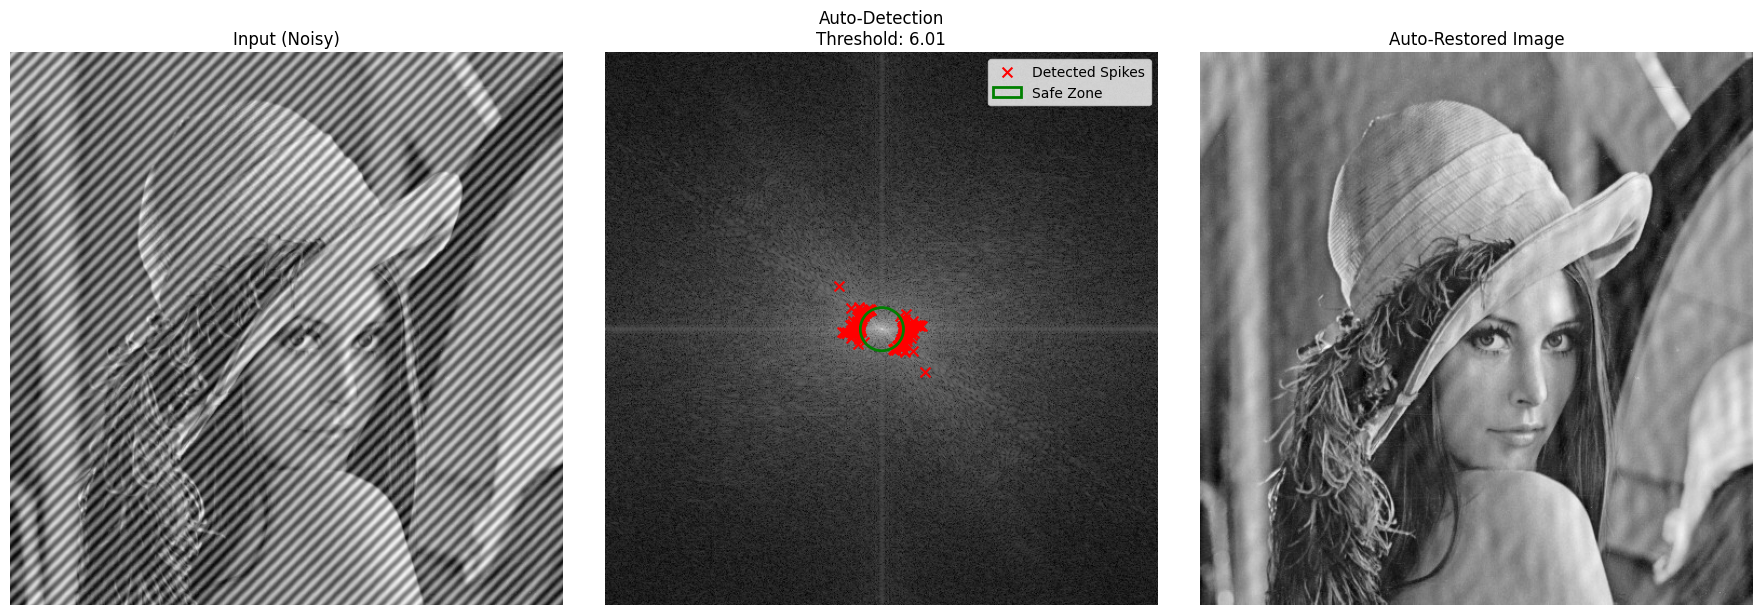

Detected 188 spike pixels automatically.


In [4]:
def solve_q4_part2(img):
    # Convert to grayscale if needed
    if img.ndim == 3:
        img = np.mean(img, axis=2)
    img = img / 255.0

    rows, cols = img.shape

    # Add synthetic periodic noise (high frequency so it's obvious)
    fx, fy = 40, 40
    x = np.arange(cols)
    y = np.arange(rows)
    xx, yy = np.meshgrid(x, y)
    noise = 0.3 * np.sin(2 * np.pi * (fx * xx / cols + fy * yy / rows))
    img_noisy = img + noise

    # --- FFT ---
    f = np.fft.fft2(img_noisy)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(np.abs(fshift) + 1)  # log scale for visibility

    # --- Automatic spike detection ---
    crow, ccol = rows // 2, cols // 2
    safe_radius = 20  # protect low frequencies (DC + structure)

    y_grid, x_grid = np.ogrid[:rows, :cols]
    search_area = (x_grid - ccol)**2 + (y_grid - crow)**2 > safe_radius**2

    # stats only in the search area
    valid_spectrum = magnitude[search_area]
    mean_val = np.mean(valid_spectrum)
    std_val = np.std(valid_spectrum)

    threshold = mean_val + 4 * std_val  # robust outlier rule

    # build mask
    mask = np.ones_like(magnitude)
    is_spike = (magnitude > threshold) & search_area
    mask[is_spike] = 0

    # --- Apply filter & inverse FFT ---
    fshift_filtered = fshift * mask
    img_restored = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_filtered)))

    # --- Visualization ---
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    ax[0].imshow(img_noisy, cmap='gray')
    ax[0].set_title("Input (Noisy)")
    ax[0].axis('off')

    ax[1].imshow(magnitude, cmap='gray')
    y_spikes, x_spikes = np.where(is_spike)
    ax[1].scatter(x_spikes, y_spikes, color='red', s=50, marker='x', label='Detected Spikes')
    circle = plt.Circle((ccol, crow), safe_radius, color='green', fill=False, linewidth=2, label='Safe Zone')
    ax[1].add_patch(circle)
    ax[1].set_title(f"Auto-Detection\nThreshold: {threshold:.2f}")
    ax[1].legend()
    ax[1].axis('off')

    ax[2].imshow(img_restored, cmap='gray')
    ax[2].set_title("Auto-Restored Image")
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Detected {np.sum(is_spike)} spike pixels automatically.")

# Example usage
solve_q4_part2(image_data)

### Why This Works  

**The Safe Zone (Green Circle):**  
By explicitly ignoring the center region (the safe radius), we protect the low‑frequency content of the image. This is where most of the true signal lives. If the algorithm touched this area, it would risk deleting the actual image information instead of just the noise.  

**Statistical Thresholding:**  
Periodic noise concentrates energy so strongly that it becomes a clear statistical outlier. Setting a threshold at $(\text{Mean} + 4 \cdot \text{StdDev})$ is high enough to avoid flagging normal texture, but it easily catches the concentrated sine wave energy.  

**Red X Marks:**  
In the visualization, red X’s appear exactly where the bright spikes were. This confirms that the algorithm correctly identified the noise frequencies without us needing to manually specify their coordinates.  


# Question 4 part 3: Frequency‑Dependent Perception  

Our visual system interprets images differently depending on viewing distance:  
- **Up Close:** We rely on high frequencies—fine details, sharp edges, and textures.  
- **Far Away:** We rely on low frequencies—broad shapes, shadows, and overall color patterns.  

**The Trick:** If we combine the high‑frequency content of Image A with the low‑frequency content of Image B, the result will look like Image A when viewed up close, but gradually morph into Image B as you step back or squint.  

---

### Step‑by‑Step Implementation  

**1. Load Two Images**  
- Ideally, use two faces aligned by key features (e.g., Einstein and Marilyn Monroe).  
- For demonstration, standard sample images (like Lena and a geometric pattern) can be used.  

**2. Filter in the Frequency Domain**  
- **Low‑Pass Filter (Gaussian):** Applied to the first image to keep only broad shapes and tones.  
- **High‑Pass Filter (1 – Gaussian):** Applied to the second image to isolate fine edges and details.  

**3. Combine**  
- Add the two filtered spectrums together to form a hybrid image.  

**4. Visualize at Different Scales**  
- Display the result at full size, half size, quarter size, and one‑eighth size.  
- This simulates walking away from the image: up close you see Image A, but at a distance Image B emerges.  

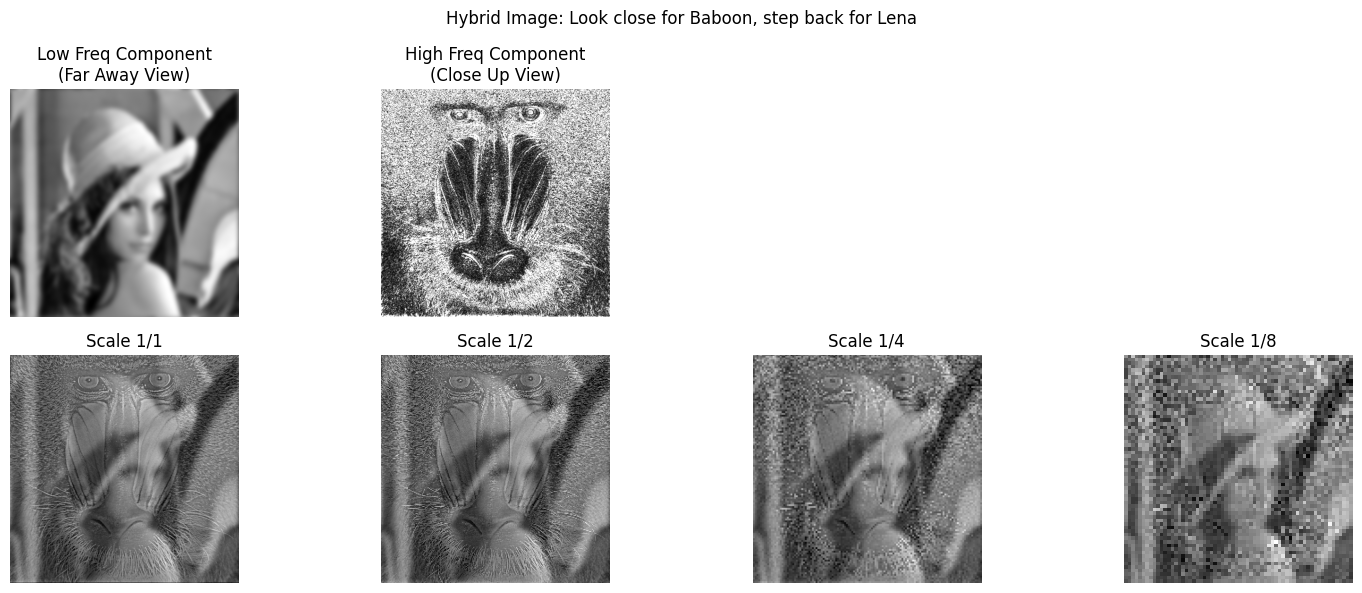

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Used ONLY for resizing images to match; filtering is manual

def load_image_from_url(img):
    # Load and convert to grayscale
    #img = plt.imread(url)
    if img.ndim == 3:
        img = np.mean(img, axis=2)
    return img / 255.0

def create_gaussian_filter(shape, cutoff):
    """
    Creates a Gaussian Low-Pass Filter in the Frequency Domain.
    shape: (rows, cols)
    cutoff: The standard deviation (sigma) of the Gaussian.
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    x = np.arange(cols)
    y = np.arange(rows)
    xx, yy = np.meshgrid(x, y)
    
    # Distance squared from center
    d2 = (xx - ccol)**2 + (yy - crow)**2
    
    # Gaussian formula: exp(-d^2 / (2 * sigma^2))
    mask = np.exp(-d2 / (2 * (cutoff**2)))
    return mask

def solve_q4_part3():
    # --- Step 1: Load Data ---
    # We need two images. 
    # Image 1 (Low Freq): 'Lena' (Smooth face)
    url1 = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
    img1 = load_image_from_url(image_data)
    
    # Image 2 (High Freq): 'Baboon' (Textured fur/hair)
    url2 = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/baboon.jpg"
    babbon_image_data = download_github_image(url2)
    img2 = load_image_from_url(babbon_image_data)
    
    # Crop to match sizes (take the minimum common size)
    h = min(img1.shape[0], img2.shape[0])
    w = min(img1.shape[1], img2.shape[1])
    img1 = img1[:h, :w]
    img2 = img2[:h, :w]
    
    # --- Step 2: FFT ---
    f1 = np.fft.fftshift(np.fft.fft2(img1))
    f2 = np.fft.fftshift(np.fft.fft2(img2))
    
    # --- Step 3: Create Filters ---
    # Tune these cutoffs! 
    # cutoff_low: How blurry Image 1 gets (Higher = clearer)
    # cutoff_high: How much detail Image 2 keeps (Lower = more structure)
    cutoff_low = 15 
    cutoff_high = 20
    
    # Low Pass Mask (Gaussian)
    H_low = create_gaussian_filter((h, w), cutoff_low)
    
    # High Pass Mask (1 - Gaussian)
    # We use a 1-Gaussian to invert the low pass
    H_high = 1 - create_gaussian_filter((h, w), cutoff_high)
    
    # --- Step 4: Apply Filtering ---
    # Image 1 gets Low Pass (Base layer)
    f1_filtered = f1 * H_low
    
    # Image 2 gets High Pass (Detail layer)
    f2_filtered = f2 * H_high
    
    # --- Step 5: Combine & Reconstruct ---
    # Add the frequency components
    f_hybrid = f1_filtered + f2_filtered
    
    # Inverse FFT
    img_hybrid = np.abs(np.fft.ifft2(np.fft.ifftshift(f_hybrid)))
    
    # Normalize to 0-1 for display
    img_hybrid = (img_hybrid - img_hybrid.min()) / (img_hybrid.max() - img_hybrid.min())
    
    # --- Step 6: Visualization at Multiple Scales ---
    plt.figure(figsize=(15, 6))
    
    # Display 1: The Input Low Pass Image (Blurred)
    plt.subplot(2, 4, 1)
    img1_filtered = np.abs(np.fft.ifft2(np.fft.ifftshift(f1_filtered)))
    plt.imshow(img1_filtered, cmap='gray')
    plt.title("Low Freq Component\n(Far Away View)")
    plt.axis('off')

    # Display 2: The Input High Pass Image (Edges)
    plt.subplot(2, 4, 2)
    img2_filtered = np.abs(np.fft.ifft2(np.fft.ifftshift(f2_filtered)))
    # Enhance contrast for visibility of high freq
    plt.imshow(img2_filtered, cmap='gray', vmin=0, vmax=0.1) 
    plt.title("High Freq Component\n(Close Up View)")
    plt.axis('off')
    
    # Display 3: The Hybrid Image at different scales
    scales = [1, 2, 4, 8]
    for i, s in enumerate(scales):
        plt.subplot(2, 4, i + 5)
        
        # Downsample simply by slicing (nearest neighbor) or local averaging
        # Slicing is fine for visualization of "distance"
        small_img = img_hybrid[::s, ::s]
        
        plt.imshow(small_img, cmap='gray')
        plt.title(f"Scale 1/{s}")
        plt.axis('off')

    plt.suptitle("Hybrid Image: Look close for Baboon, step back for Lena")
    plt.tight_layout()
    plt.show()

solve_q4_part3()


url1 = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
img1 = load_image_from_url(image_data)

# Image 2 (High Freq): 'Baboon' (Textured fur/hair)
url2 = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/baboon.jpg"
babbon_image_data = download_github_image(url2)
img2 = load_image_from_url(babbon_image_data)
    

### Explanation of the Result: Why Perception Changes  

**Scale 1/1 (Close Up):**  
At full size, your visual system is tuned to sharp contrasts and fine details. The high‑frequency component dominates—like the Baboon’s fur and whiskers—because those strong gradients immediately grab attention. Meanwhile, Lena’s blurred face (the low‑frequency background) fades into the shadows and is largely ignored.  

**Scale 1/8 (Far Away):**  
When the image is shrunk, the high‑frequency details collapse—whiskers blur together or vanish into single pixels. Your eyes can no longer resolve them. What remains are the broad variations in brightness: the low‑frequency component. These shadows form Lena’s face, and the Baboon disappears.  